In [16]:
import copy
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from ax.api.client import Client

In [17]:
client = Client()
Emu_GP_Mat05 = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_M05.json")
Emu_GP_Mat05.get_next_trials(max_trials=1)
Emu_GP_Mat15 = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_M15.json")
Emu_GP_Mat15.get_next_trials(max_trials=1)
Emu_GP_Mat25 = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_M25.json")
Emu_GP_Mat25.get_next_trials(max_trials=1)
Emu_GP_RBF = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelGP/ModelGP_RBF.json")
Emu_GP_RBF.get_next_trials(max_trials=1)
Emu_XGB = xgb.XGBRegressor()
Emu_XGB.load_model("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/sandbox/Emulation/StoichModelXG/ModelXG.json")

In [18]:
n = 100
feature_x = np.linspace(0.5,1.0,n)
feature_y = np.linspace(0.25,0.50,n)
[X, Y] = np.meshgrid(feature_x, feature_y)

Z_GP_Mat05 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat05[row][column] = Emu_GP_Mat05.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("A")

Z_GP_Mat15 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat15[row][column] = Emu_GP_Mat15.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("B")

Z_GP_Mat25 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat25[row][column] = Emu_GP_Mat25.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("C")

Z_GP_RBF = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_RBF[row][column] = Emu_GP_RBF.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("D")

Z_XGB = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_XGB[row][column] = Emu_XGB.predict(([[X[row][column],Y[row][column]]]))[0]
print("E")

Zs = [Z_GP_Mat05,Z_GP_Mat15,Z_GP_Mat25,Z_GP_RBF,Z_XGB]

A
B
C
D
E


In [19]:
EmulatorNames = ["GP-Mat-05",
                 "GP-Mat-15",
                 "GP-Mat-25",
                 "GP-Rbf",
                 "Xgb"]

In [22]:
EmulatorMaximums_lis = []
for Z in Zs:
    EmulatorMaximums_lis.append(round(np.max(Z),2))
EmulatorMaximums_arr = np.array(EmulatorMaximums_lis)
print(EmulatorMaximums_arr)

[18.57 18.27 18.29 15.14 19.14]


In [23]:
for EmulatorName,EmulatorMaximum in zip(EmulatorNames,EmulatorMaximums_lis):
    print(f"{EmulatorName}:\t{EmulatorMaximum}")

GP-Mat-05:	18.57
GP-Mat-15:	18.27
GP-Mat-25:	18.29
GP-Rbf:	15.14
Xgb:	19.14


In [6]:
def PredictorsToCaStoichs(s1,b1):
    return (0.5+(2.0-0.5)*s1)*b1

def PredictorsToIaStoichs(s2,b1):
    return (1.0+(2.0-1.0)*s2)*(1-b1)

A
B
C
D
E


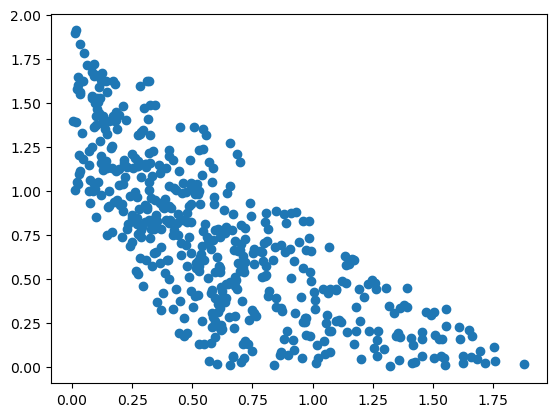

In [ ]:
n = 500

x1s = np.random.uniform(0,1,n)
x2s = np.random.uniform(0,1,n)
x3s = np.random.uniform(0,1,n)

CiIts = []
for x1,x2,x3 in zip(x1s,x2s,x3s):
    Ci = PredictorsToCaStoichs(x1,x3)
    It = PredictorsToIaStoichs(x2,x3)
    CiIts.append([Ci,It])
CiIts_arr = np.array(CiIts)

Ci_arr = CiIts_arr.T[0]
It_arr = CiIts_arr.T[1]

[X, Y] = np.meshgrid(Ci_arr, It_arr)

Z_GP_Mat05 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat05[row][column] = Emu_GP_Mat05.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("A")

Z_GP_Mat15 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat15[row][column] = Emu_GP_Mat15.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("B")

Z_GP_Mat25 = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_Mat25[row][column] = Emu_GP_Mat25.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("C")

Z_GP_RBF = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_GP_RBF[row][column] = Emu_GP_RBF.predict([{"n_ci":X[row][column],"n_it":Y[row][column]}])[0]["t1"][0]
print("D")

Z_XGB = copy.deepcopy(X)
for column in range(0,len(X[0])):
    for row in range(0,len(X.T[0])):
        Z_XGB[row][column] = Emu_XGB.predict(([[X[row][column],Y[row][column]]]))[0]
print("E")

Zs = [Z_GP_Mat05,Z_GP_Mat15,Z_GP_Mat25,Z_GP_RBF,Z_XGB]

# # e.g. XGB
fig, ax = plt.subplots(1, 1)
ax.scatter(Ci_arr,It_arr)

In [15]:
EmulatorMinimums_lis = []
for Z in Zs:
    EmulatorMinimums_lis.append(round(np.min(Z),2))
EmulatorMinimums_arr = np.array(EmulatorMinimums_lis)
print(EmulatorMinimums_arr)

[10.7  10.77 10.8  10.81  9.89]


In [24]:
for EmulatorName,EmulatorMinimum in zip(EmulatorNames,EmulatorMinimums_arr):
    print(f"{EmulatorName}:\t{EmulatorMinimum}")

GP-Mat-05:	10.7
GP-Mat-15:	10.77
GP-Mat-25:	10.8
GP-Rbf:	10.81
Xgb:	9.89
